In [ ]:
import os # delete some of the redundant imports later
import json
import zipfile
import warnings
import pandas as pd
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pandas_datareader import data as pdr
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FuncFormatter
from helper_figure_plotters import download_and_resample_yahoo, plot_five_models

warnings.filterwarnings("ignore")
figure_path = os.path.join(os.getcwd(), '..', 'figures')
color_list = ['#486cb0', '#fed07e', '#e75948']
color_list = [(0/255, 28/255, 84/255, 0.8), '#E89818', '#8b0000']
fill_color = (254/255, 208/255, 126/255, 10/255)
mpl.rcParams['font.family'] = 'Helvetica'

import importlib
import helper_figure_plotters as hfp
importlib.reload(hfp)
from helper_figure_plotters import load_sympt,\
                                   plot_predictions,\
                                   plot_mvprobit,\
                                   plot_four_simple_examples,\
                                   plot_collisions,\
                                   plot_topics_barplot,\
                                   plot_ffc, plot_four_rws,\
                                   plot_further_examples,\
                                   plot_schelling_examples,\
                                   load_scientometrics,\
                                   desc_print_scientometrics,\
                                   make_table,\
                                   make_scientometric_ts,\
                                   plot_scientometrics,\
                                   plot_new_scientometrics,\
                                   plot_two_inference,\
                                   plot_three_simple_examples,\
                                   plot_mcs_single,\
                                   plot_mcs_pair

warnings.filterwarnings("ignore")
figure_path = os.path.join(os.getcwd(), '..', 'figures')
#color_list = ['#486cb0', '#fed07e', '#e75948']
color_list = [(0/255, 28/255, 84/255, 0.8), '#E89818', '#8b0000', '#91cf60']


fill_color = (254/255, 208/255, 126/255, 10/255)
mpl.rcParams['font.family'] = 'Helvetica'


In [ ]:
df_rng, df_hrng, df_qrng, df_prng, df_quarng, df_yr, df_yr_dom, df_dom = load_scientometrics()
df_yr = make_scientometric_ts(df_rng, df_hrng, df_qrng, df_prng, df_quarng, df_yr, df_dom)
df_yr = df_yr.set_index('year')
latest_year = int(df_yr.index.max())
for rng_type in ['RNG_count', 'HRNG_count', 'QRNG_count', 'PRNG_count', 'QUASI_count']:
    print('The percent of OpenAlex which is focused on ' + rng_type.split('_')[0] +
          ' in year 1970 is ' + str(df_yr.loc[1970, rng_type].round(4)))
    print('The percent of OpenAlex which is focused on ' + rng_type.split('_')[0] +
          f' in year {latest_year} is ' + str(df_yr.loc[latest_year, rng_type].round(4)))


In [ ]:
rng_total = len(df_rng)
global_total = int(df_yr['total_count'].sum())
global_pct = rng_total / global_total * 100
print(f"Global percent of OpenAlex focused on random numbers: {global_pct:.4f}%")
print(f"Numerator (random number papers): {rng_total}")
print(f"Denominator (all papers in dataset): {global_total}")


In [ ]:
desc_print_scientometrics(df_rng, df_hrng, df_qrng, df_prng, df_quarng)

In [ ]:
l2 = make_table(df_rng, df_hrng, df_qrng, df_prng, df_quarng, 'field')
l2.to_csv('../tables/l2_table.csv')
l2

In [ ]:
df_dom.loc[0, 'domain'] = 'Life Sciences' # Is this right?
df_dom.loc[1, 'domain'] = 'Social Sciences'
df_dom.loc[2, 'domain'] = 'Physical Sciences'
df_dom.loc[3, 'domain'] = 'Health Sciences'
df_dom = df_dom.set_index('domain')
domain_df = make_table(df_rng, df_hrng, df_qrng, df_prng, df_quarng, 'domain')
domain_df = domain_df.div(df_dom['count'], axis=0)*100
domain_df.to_csv('../tables/domain_table.csv')
domain_df

In [ ]:
df_rng, df_hrng, df_qrng, df_prng, df_quarng, df_yr, df_yr_dom, df_dom = load_scientometrics()
df_yr = make_scientometric_ts(df_rng, df_hrng, df_qrng, df_prng, df_quarng, df_yr, domain_df)
df_yr = df_yr.set_index('year')
for rng_type in ['RNG_count', 'HRNG_count', 'QRNG_count', 'PRNG_count', 'QUASI_count']:
    print('The percent of OpenAlex which is focused on ' + rng_type.split('_')[0] +
          ' in year 1970 is ' + str(df_yr.loc[1970, rng_type].round(4)))
    print('The percent of OpenAlex which is focused on ' + rng_type.split('_')[0] +
          ' in year 2025 is ' + str(df_yr.loc[2025, rng_type].round(4)))

In [ ]:
plot_new_scientometrics()

In [ ]:
#plot_three_simple_examples(figure_path, figsize=(8.5, 17), colors = ['#4575b4', '#E6AC00', '#d73027'],
#                           fill_color = (254 / 255, 208 / 255, 126 / 255, 10 / 255))

In [ ]:
ffc = pd.read_csv(os.path.join(os.getcwd(), '..', 'data', 'ffc',
                               'output', 'seed',
                               'seed_analysis_10000.csv'))
plot_ffc(ffc, figure_path)

In [ ]:
merged_mcs_path = os.path.join(os.getcwd(), '..', 'data', 'mcs', 'results', 'merged_files', 'merged_csvs.csv')
if os.path.exists(merged_mcs_path):
    plot_mcs_pair(merged_mcs_path, figsize=(14, 8))
else:
    print(f"Merged MCS CSV not found at {merged_mcs_path}")

[plot_five_models] US/GBP RW final-day distribution: mean=0.8297, min=0.6345, max=1.0719, sd=0.0459, z=18.0743
[plot_five_models] schelling (empty=0.3, threshold=0.3) steps: mean=8.5294, min=4.0000, max=29.0000, sd=2.2065, z=3.8656
Science topics: mean=240.2947, min=5.0000, max=629.0000, sd=248.8805, z=0.9655
MNIST accuracy: mean=9623.3025, min=9001.0000, max=9728.0000, sd=65.8820, z=146.0688
MNIST accuracy for seed 42: 9625
MNIST accuracy for seed 123: 9690
The minimum USD/GBP RW forecast is: 0.6344813157389798
The maximum USD/GBP RW forecast is: 1.0718573382939551
The median USD/GBP RW forecast is: 0.8284735406215726
Schelling convergence min/max: 4 29
rho21 @ draws=2: min=-0.533909, mean=-0.147588, max=0.251475, sd=0.123195, z=-1.198001
rho21 @ draws=150: min=-0.352423, mean=-0.266280, max=-0.184698, sd=0.024873, z=-10.705578


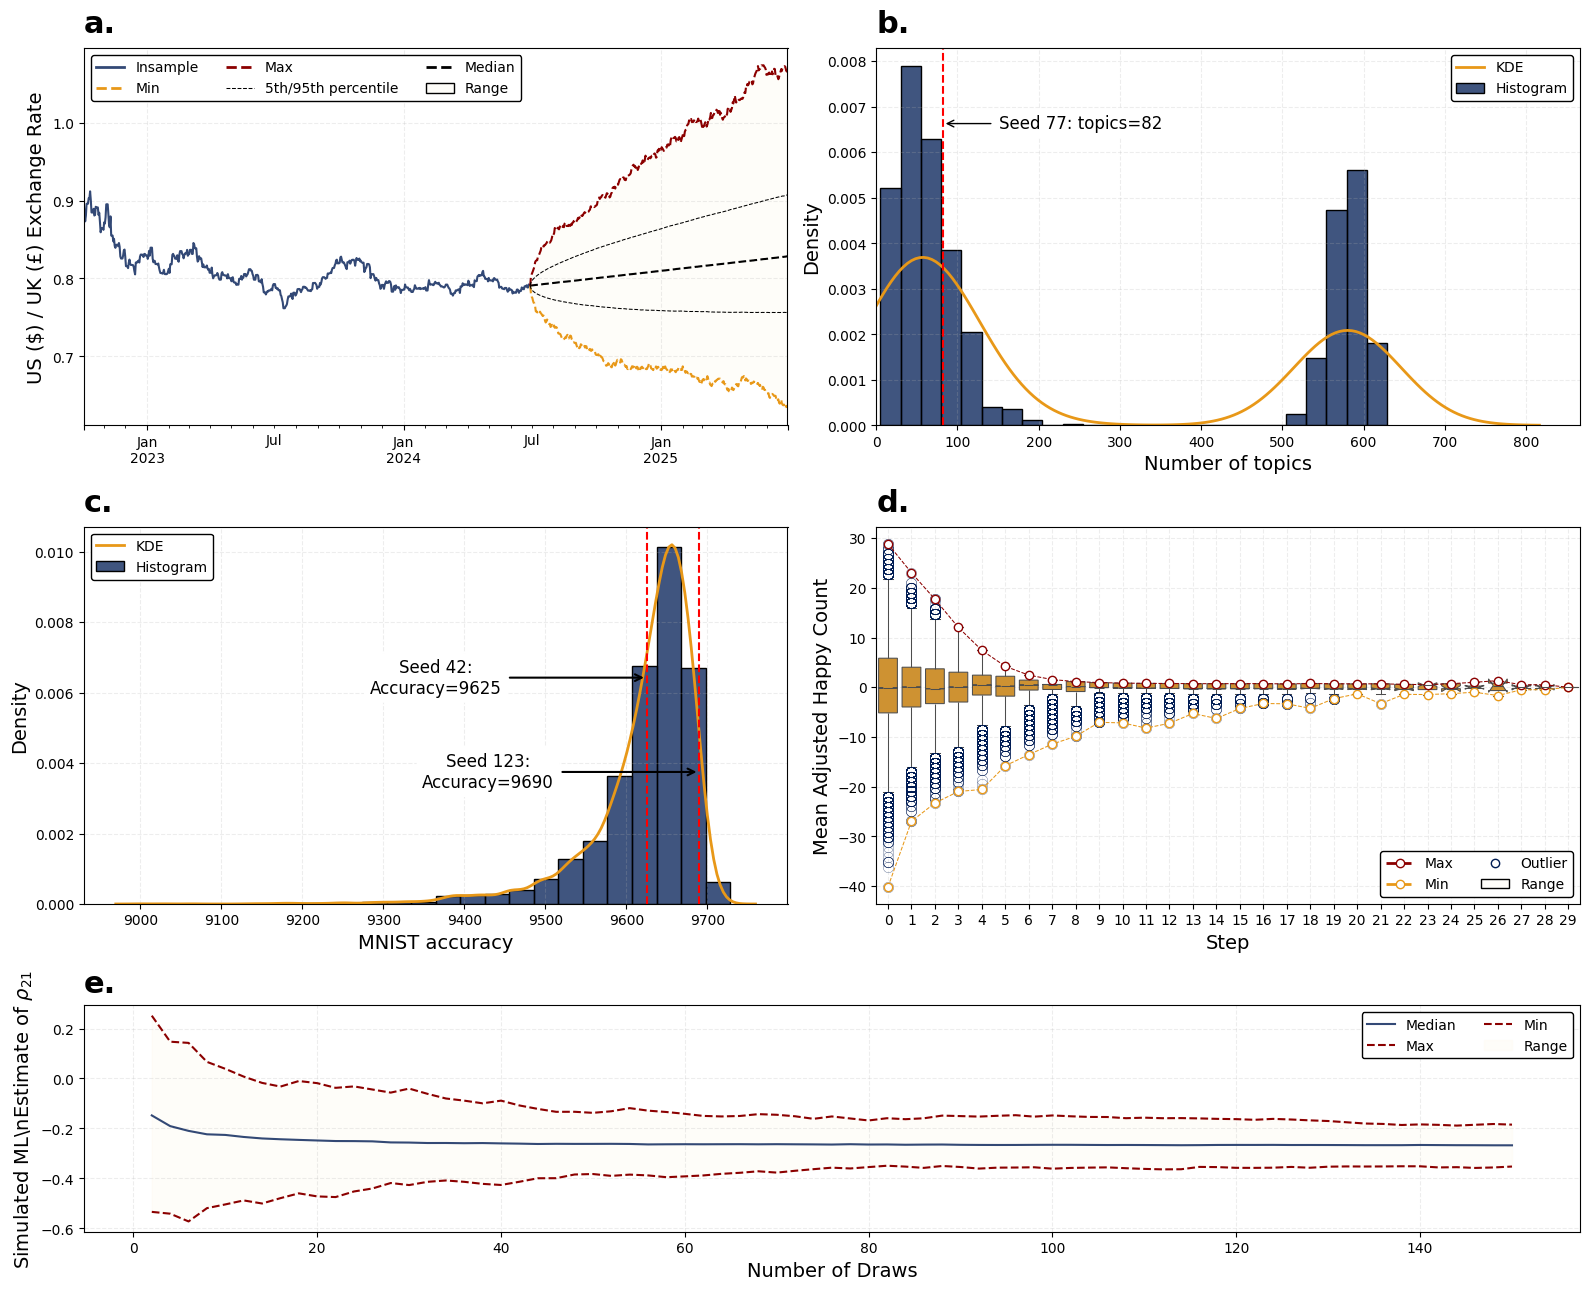

In [1]:
from helper_figure_plotters import plot_five_models
plot_five_models()

[plot_schelling_examples] empty=0.3 threshold=0.5 steps -> min=4, mean=10.32, max=33, sd=3.0683, z=3.3622
[plot_schelling_examples] empty=0.5 threshold=0.3 steps -> min=3, mean=9.30, max=33, sd=3.0959, z=3.0025
[plot_schelling_examples] empty=0.5 threshold=0.5 steps -> min=3, mean=9.56, max=33, sd=2.9813, z=3.2051


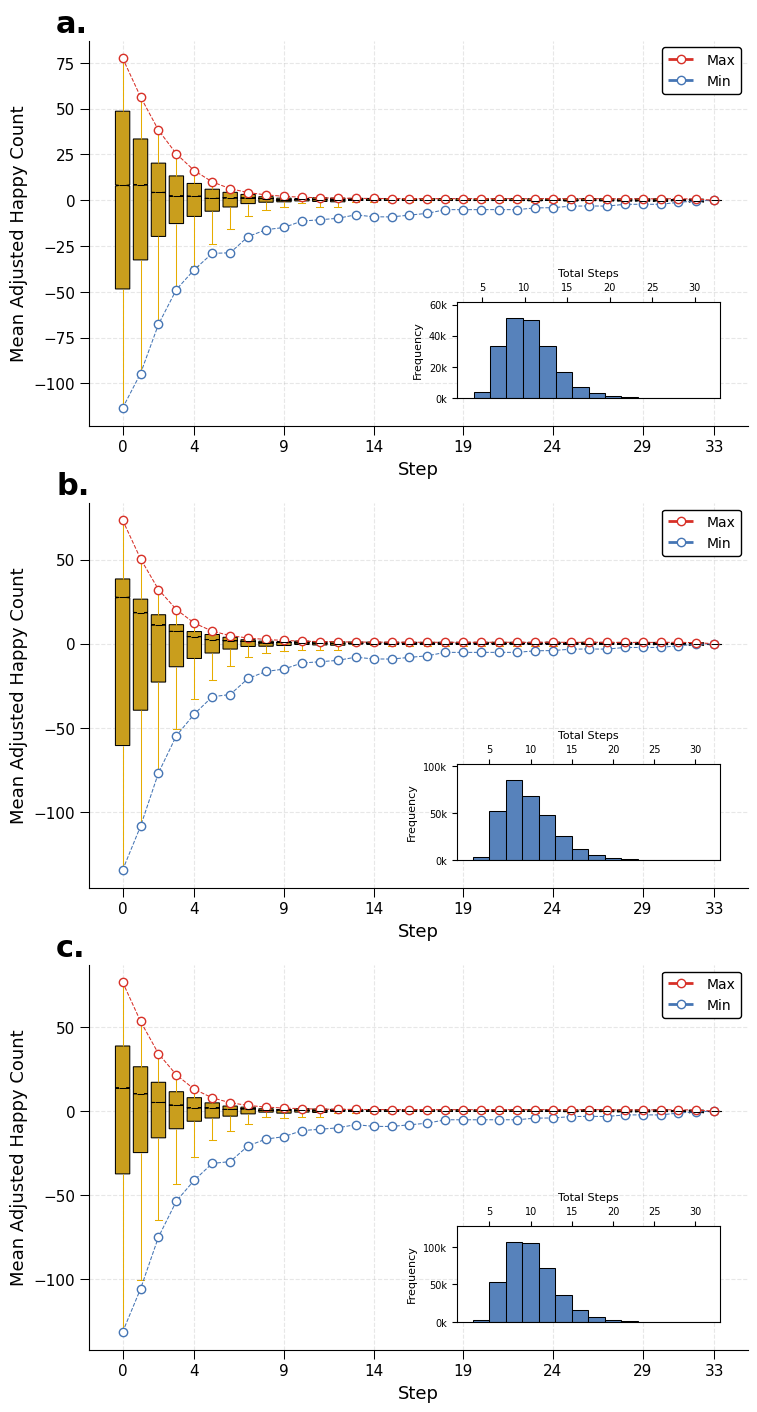

In [1]:
from helper_figure_plotters import plot_schelling_examples
plot_schelling_examples()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[plot_three_supplementary_rws] BTC RW final-day: mean=87218.7568, min=23895.9876, max=297047.1991, sd=25141.8946, z=3.4691
[plot_three_supplementary_rws] NASDAQ RW final-day: mean=20304.2511, min=10384.9685, max=38119.6979, sd=2827.7735, z=7.1803
[plot_three_supplementary_rws] NVDA RW final-day: mean=367.9763, min=90.6297, max=1318.4583, sd=123.5881, z=2.9774


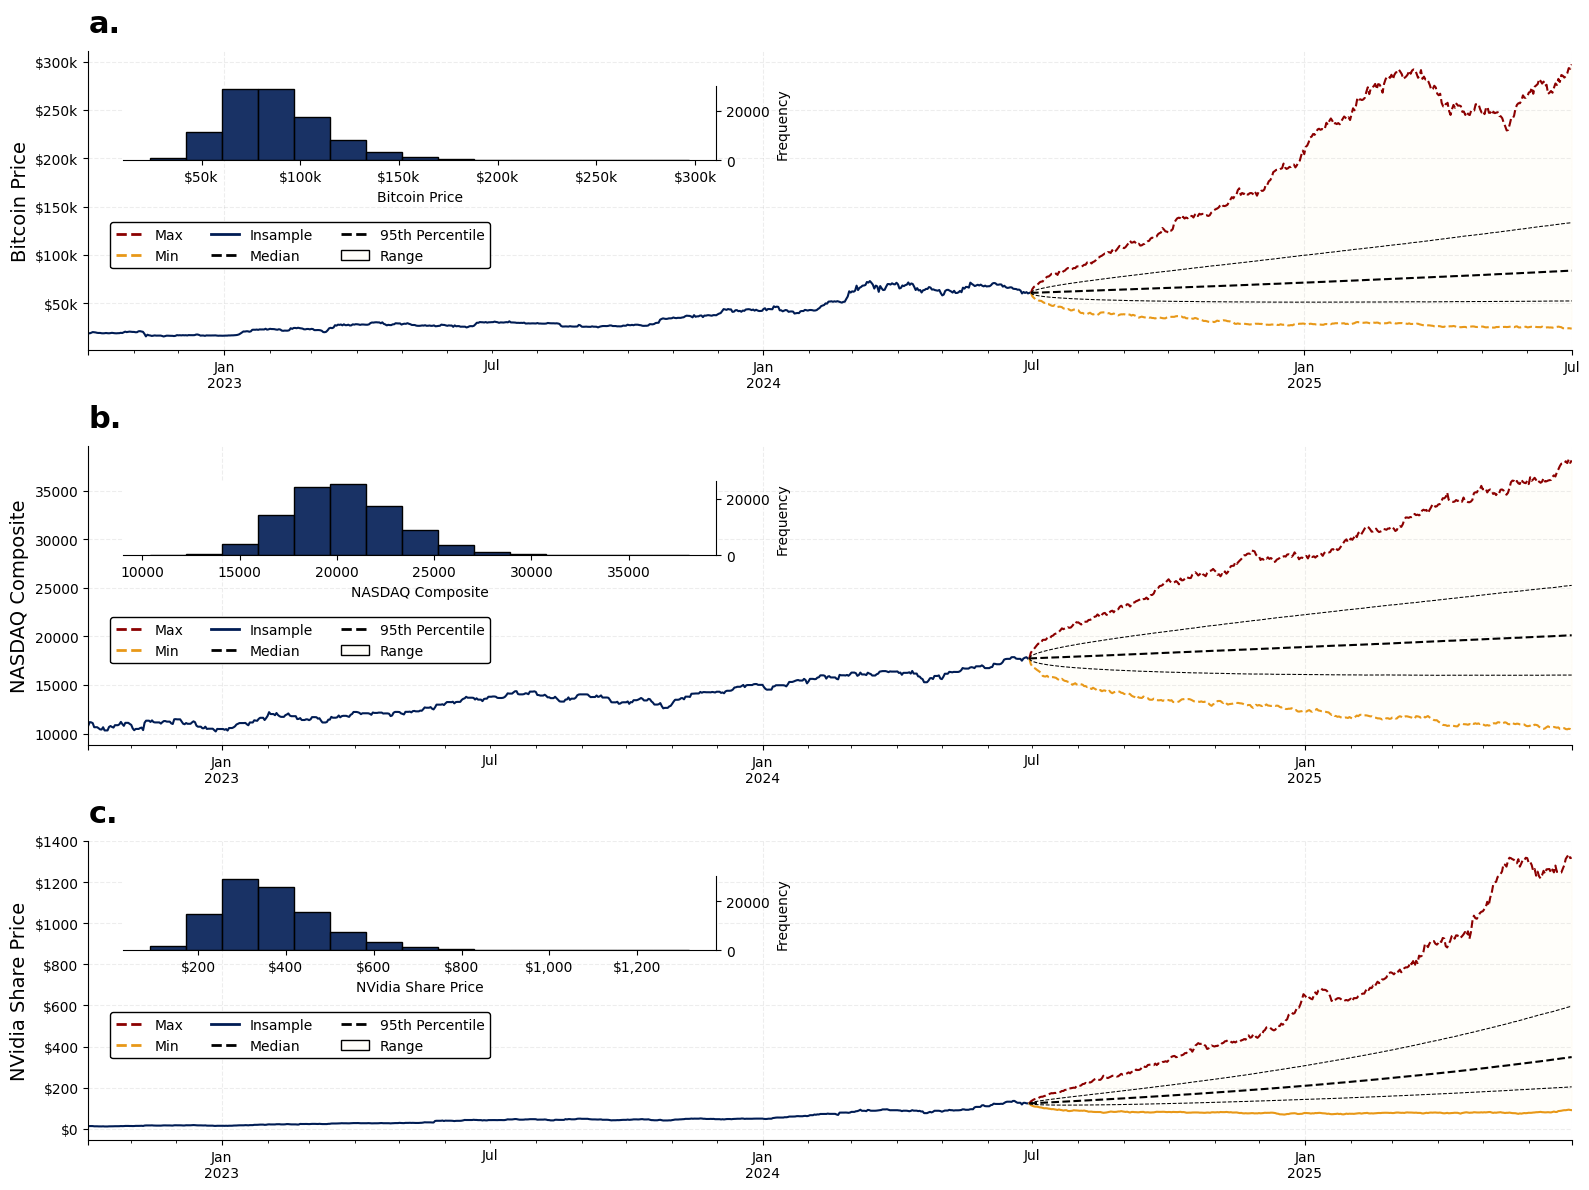

In [1]:
from helper_figure_plotters import plot_three_supplementary_rws
plot_three_supplementary_rws(figsize=(16, 12))

In [ ]:
from helper_figure_plotters import plot_topics_supplement
plot_topics_supplement(figsize=(16, 12))

In [ ]:
from helper_figure_plotters import plot_topics_supplement2
plot_topics_supplement2(figsize=(9, 7))

[plot_compas_recidivism] African-American flip% (any flip>0): lr=26.1% (N=3175), rf=45.1% (N=3175), nn=58.9% (N=3175)


/home/jinx/Dropbox/seeds/src/helper_figure_plotters.py:5098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


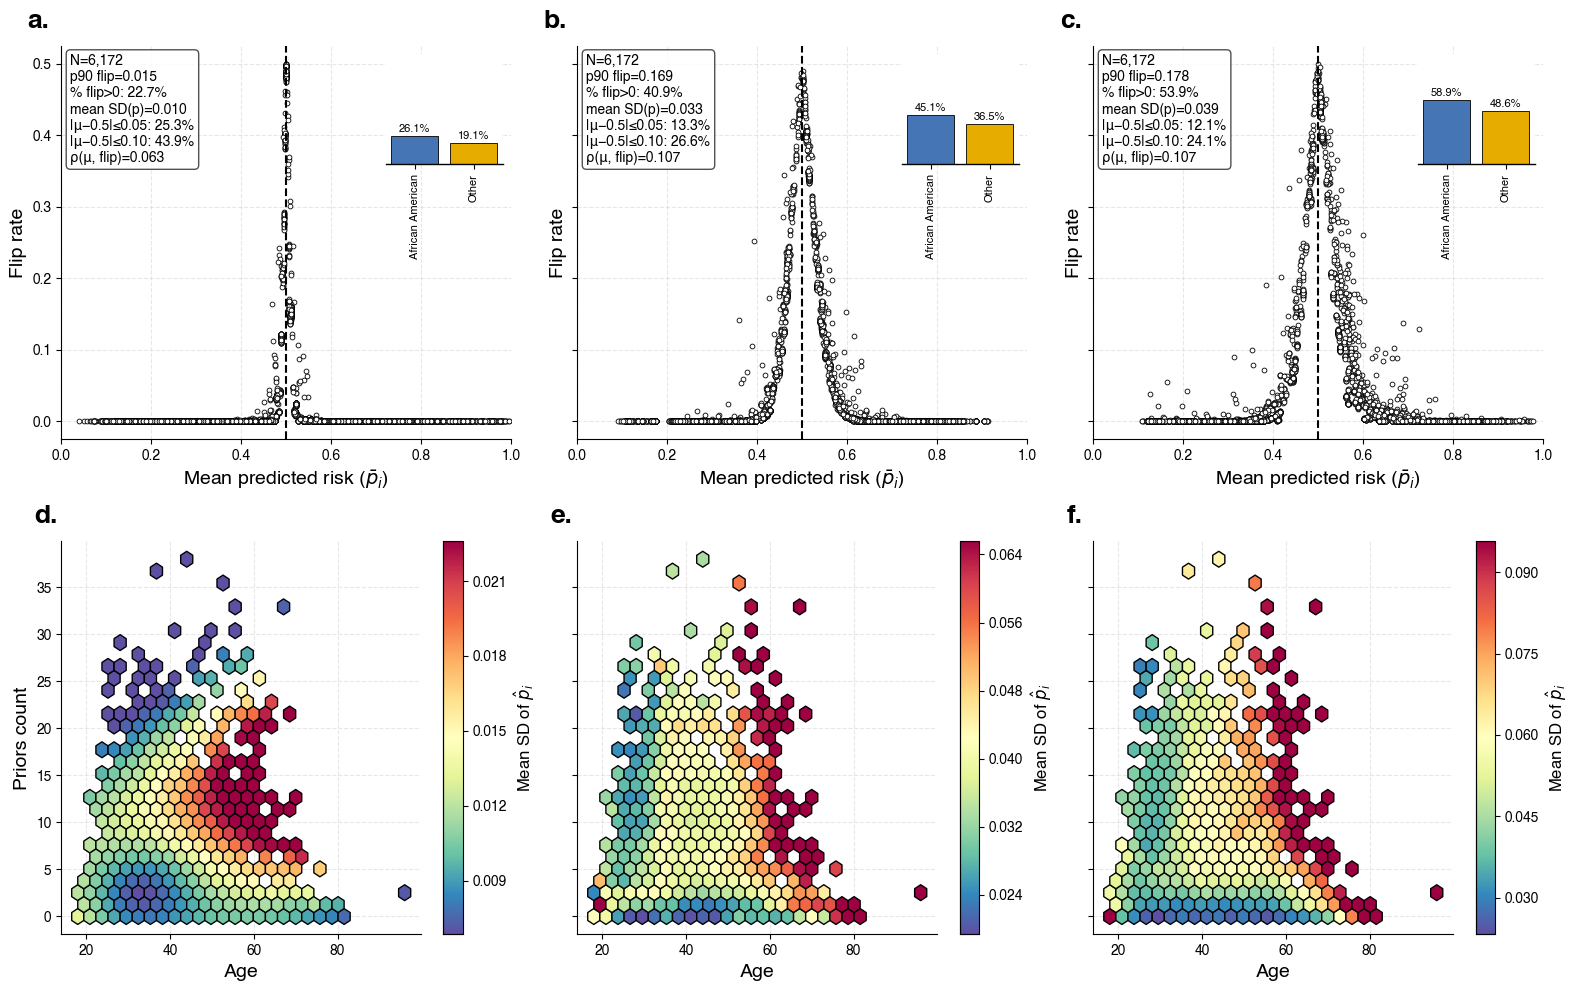

In [2]:
from helper_figure_plotters import plot_compas_recidivism
plot_compas_recidivism()



===================== SAMPLE SIZE / SEED TRIALS =====================
Main file '../data/llms/results_shuffled.csv' (different seeds): rows=90,000 | unique temperatures=[np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0), np.float64(1.25), np.float64(1.5), np.float64(1.75), np.float64(2.0)] | unique seeds=10000
  - temp 0.0: rows=10,000 | unique seeds=10000
  - temp 0.25: rows=10,000 | unique seeds=10000
  - temp 0.5: rows=10,000 | unique seeds=10000
  - temp 0.75: rows=10,000 | unique seeds=10000
  - temp 1.0: rows=10,000 | unique seeds=10000
  - temp 1.25: rows=10,000 | unique seeds=10000
  - temp 1.5: rows=10,000 | unique seeds=10000
  - temp 1.75: rows=10,000 | unique seeds=10000
  - temp 2.0: rows=10,000 | unique seeds=10000
Fixed-seed file '../data/llms/results_fixed_seed_temp0.csv' (includes temp sweeps): rows=1,000 | unique temperatures=[np.float64(0.0)] | unique seeds=1
  - temp 0.0: rows=1,000 | unique seeds=1
Fixed-seed @ temperature 0.0 s

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
webf NOT subset; don't know how to subset; dropped


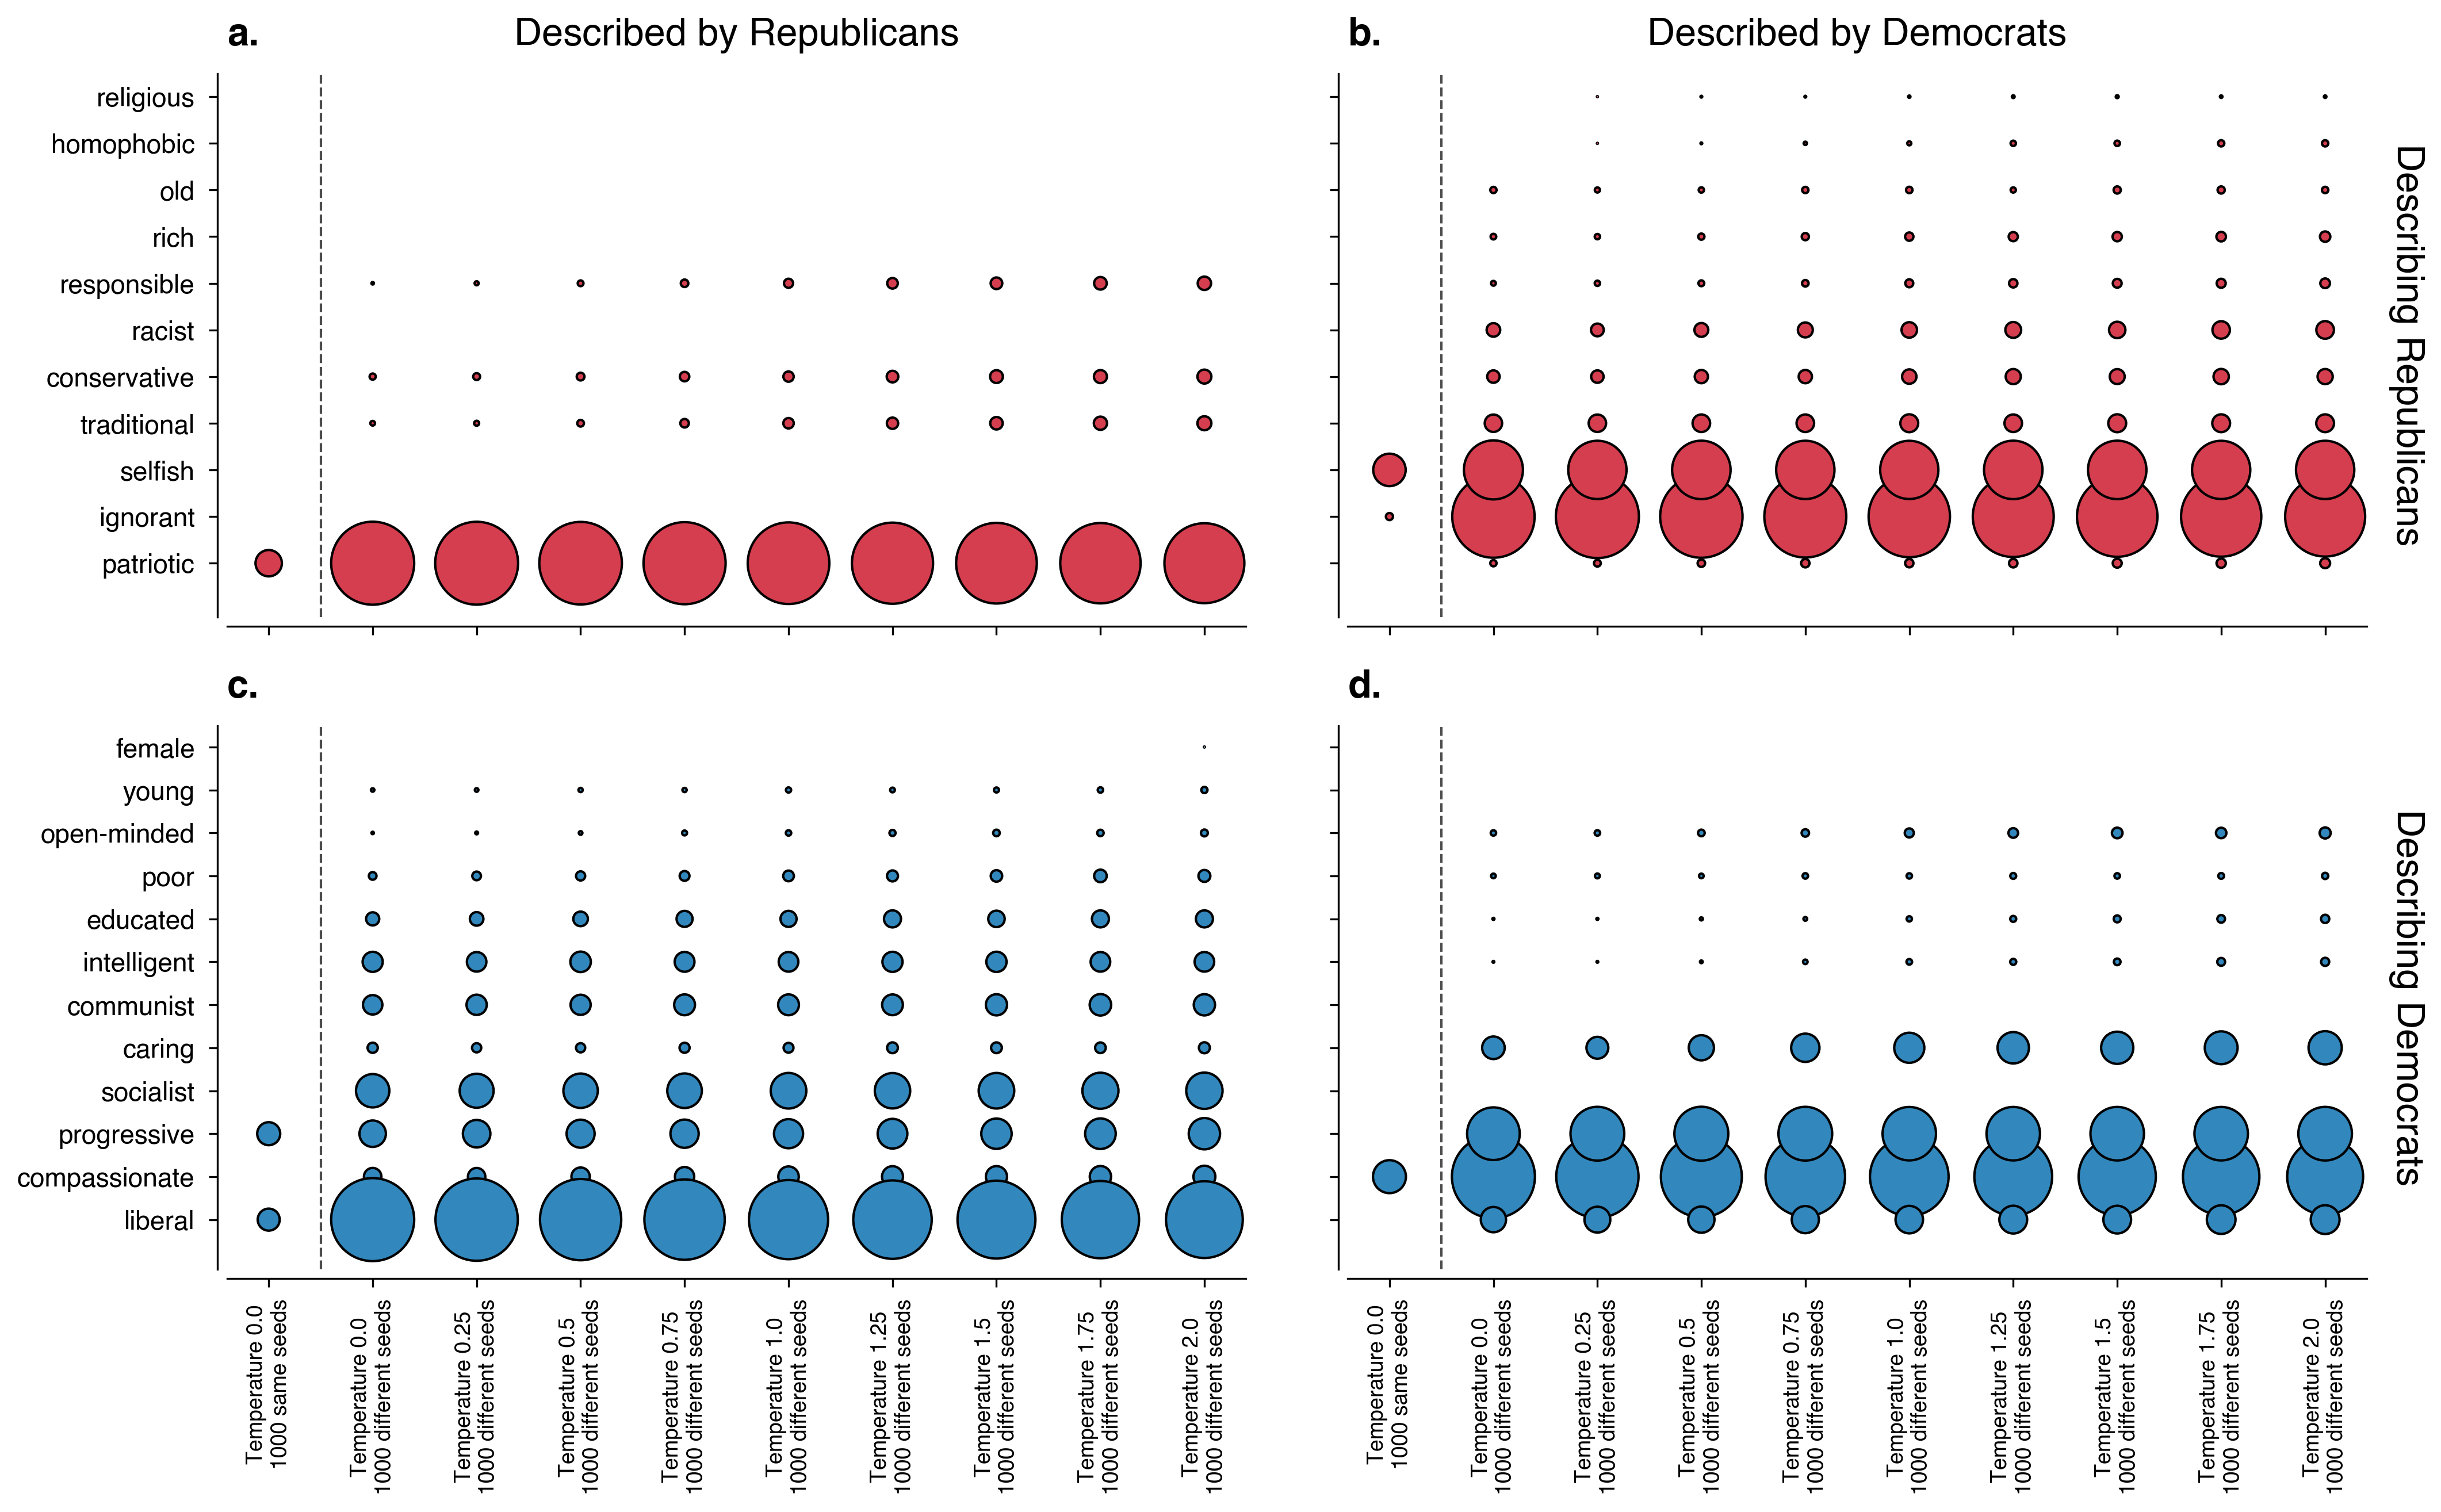

In [1]:
from helper_figure_plotters import plot_llms

plot_llms("../data/llms/results_shuffled.csv",
          "../data/llms/results_fixed_seed_temp0.csv",
          shuffled="shuffled")


===================== SAMPLE SIZE / SEED TRIALS =====================
Main file '../data/llms/results_noshuffled.csv' (different seeds): rows=90,000 | unique temperatures=[np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0), np.float64(1.25), np.float64(1.5), np.float64(1.75), np.float64(2.0)] | unique seeds=10000
  - temp 0.0: rows=10,000 | unique seeds=10000
  - temp 0.25: rows=10,000 | unique seeds=10000
  - temp 0.5: rows=10,000 | unique seeds=10000
  - temp 0.75: rows=10,000 | unique seeds=10000
  - temp 1.0: rows=10,000 | unique seeds=10000
  - temp 1.25: rows=10,000 | unique seeds=10000
  - temp 1.5: rows=10,000 | unique seeds=10000
  - temp 1.75: rows=10,000 | unique seeds=10000
  - temp 2.0: rows=10,000 | unique seeds=10000
Fixed-seed file '../data/llms/results_fixed_seed_temp0_no_shuffle.csv' (includes temp sweeps): rows=1,000 | unique temperatures=[np.float64(0.0)] | unique seeds=1
  - temp 0.0: rows=1,000 | unique seeds=1
Fixed-seed @ temp

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
webf NOT subset; don't know how to subset; dropped


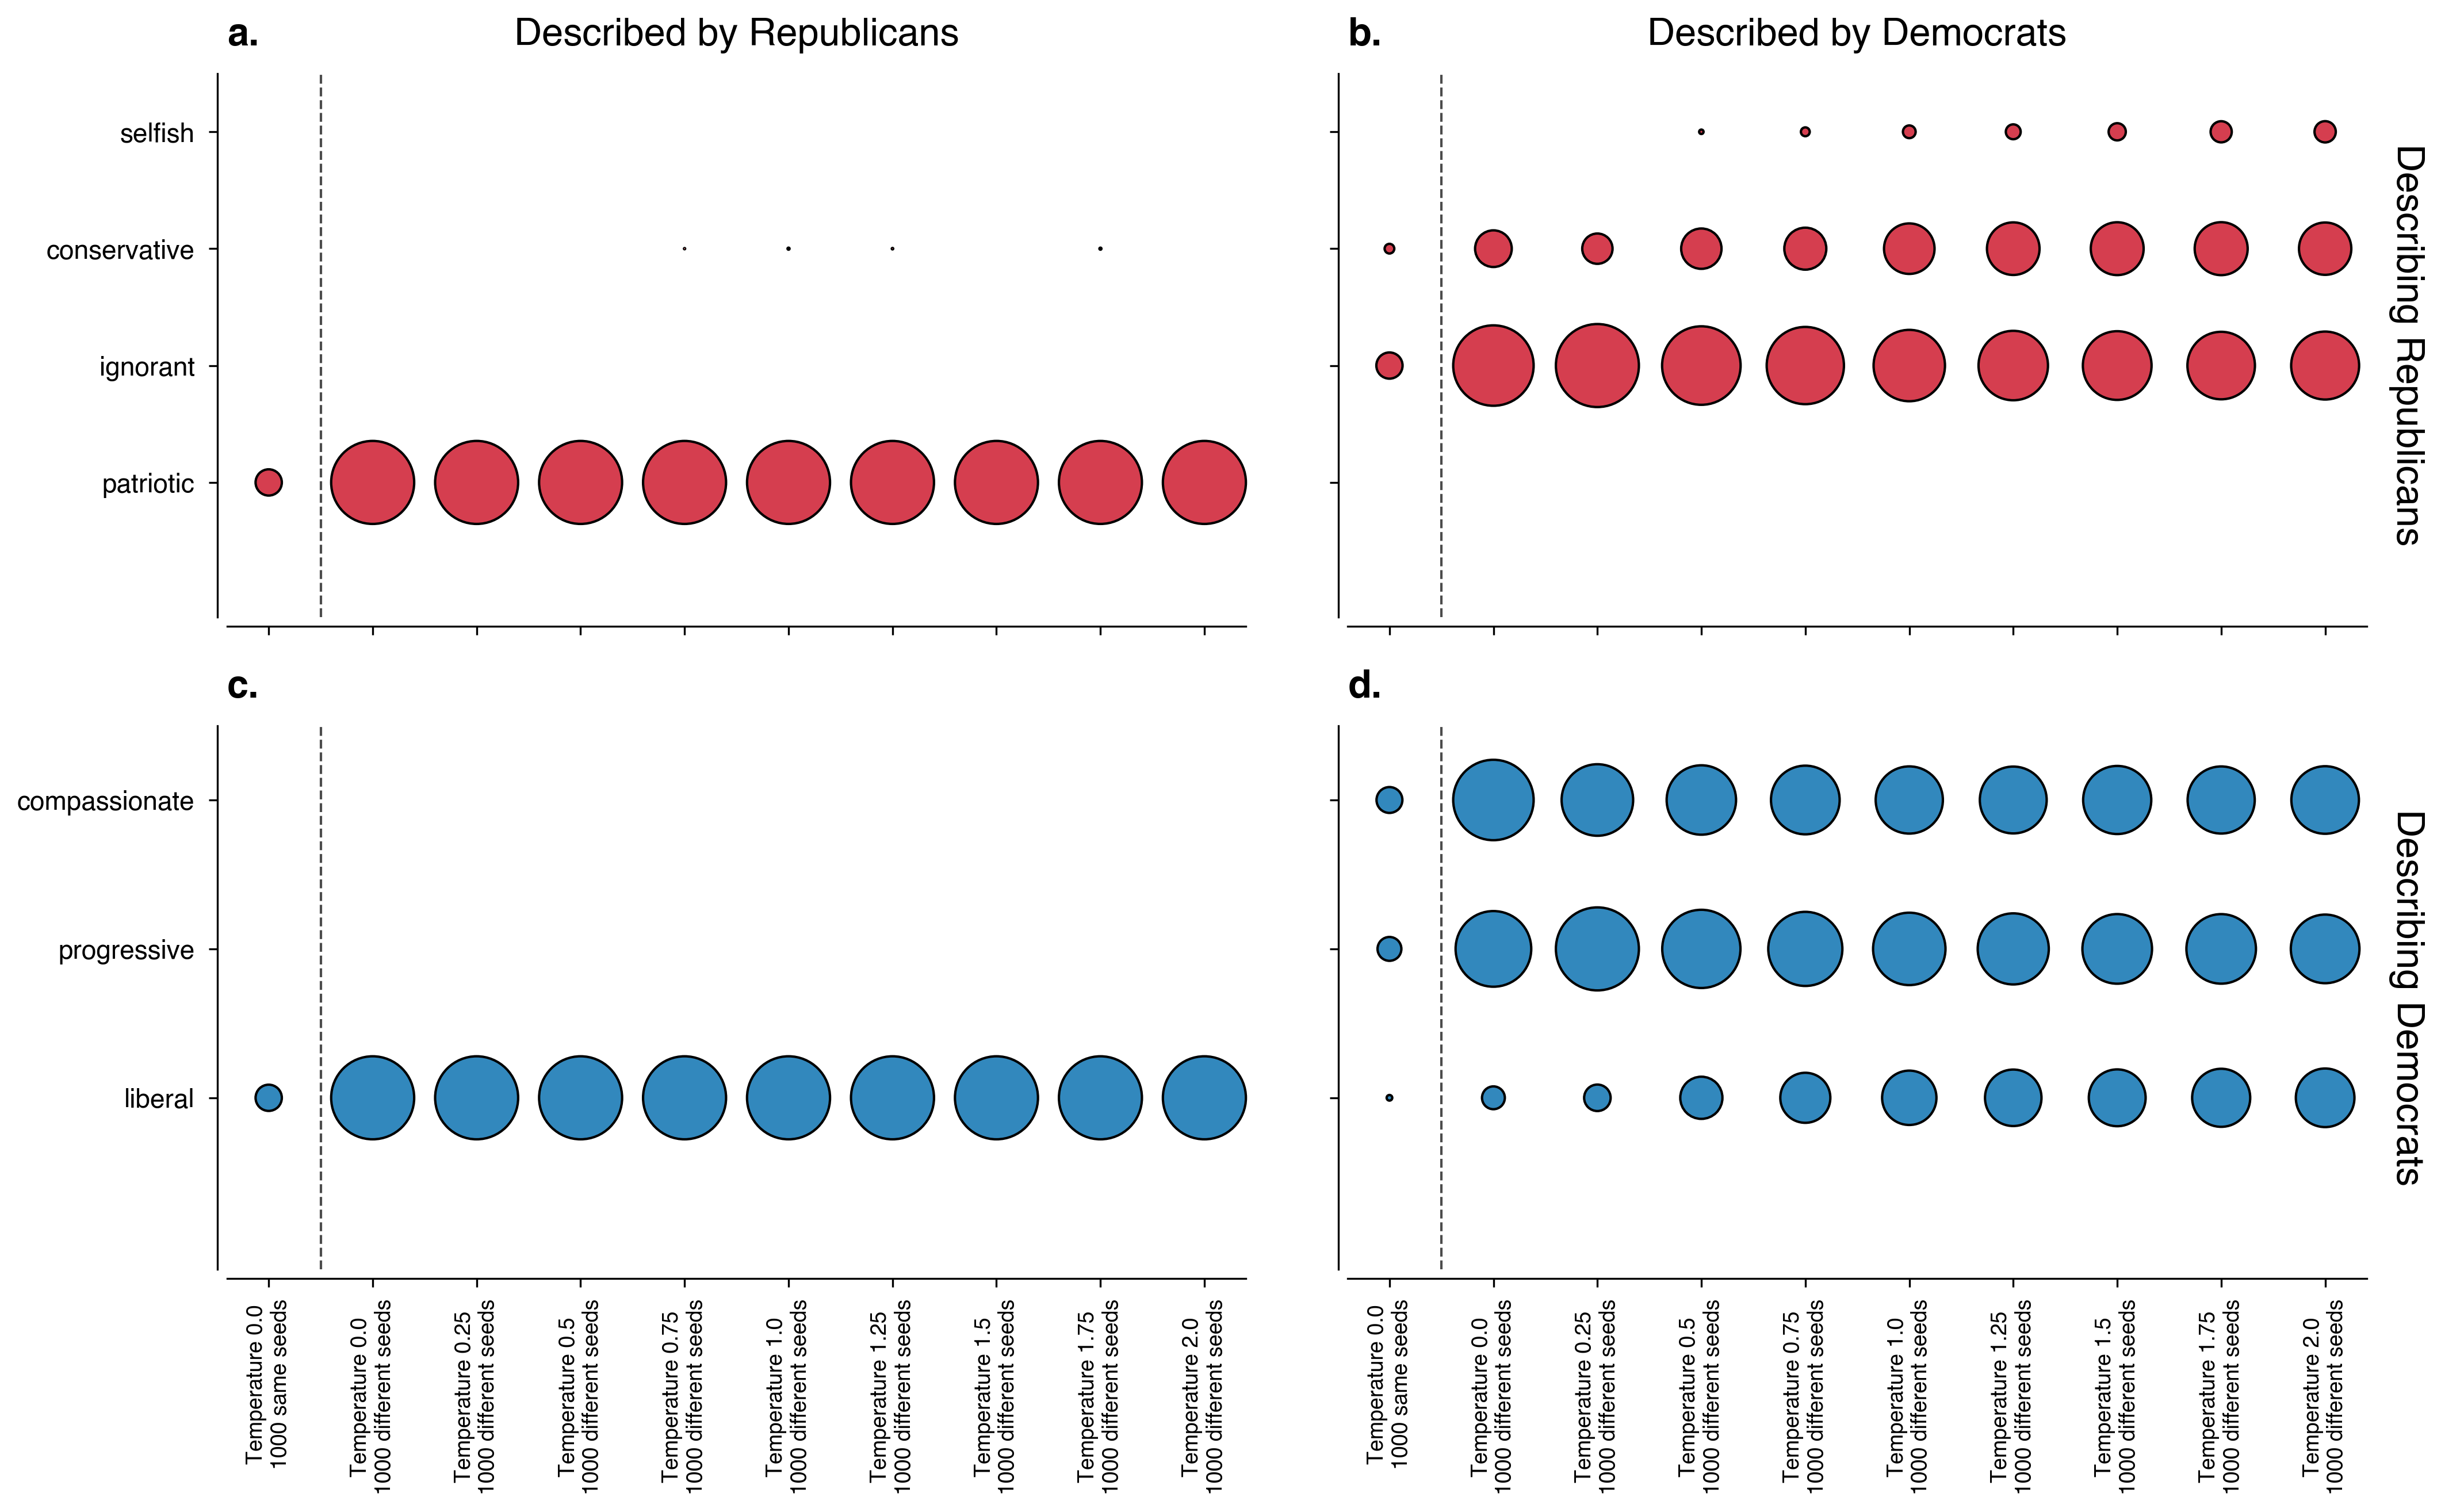

In [3]:
plot_llms("../data/llms/results_noshuffled.csv",
          "../data/llms/results_fixed_seed_temp0_no_shuffle.csv",
          "notshuffled")

50000
COVID ROC-AUC (all folds): n=50000, mean=0.7431, min=0.6706, max=0.8123, sd=0.0166, z=44.8096
Housing R2 (OLS): n=1000, mean=0.6356, min=0.6048, max=0.6611, sd=0.0091, z=69.9897
Titanic IMV (Logistic Regression): n=10000, mean=0.3763, min=0.3335, max=0.4819, sd=0.0181, z=20.7965
COVID ROC-AUC (row means across folds): n=10000, mean=0.7431, min=0.7374, max=0.7461, sd=0.0010, z=761.5867


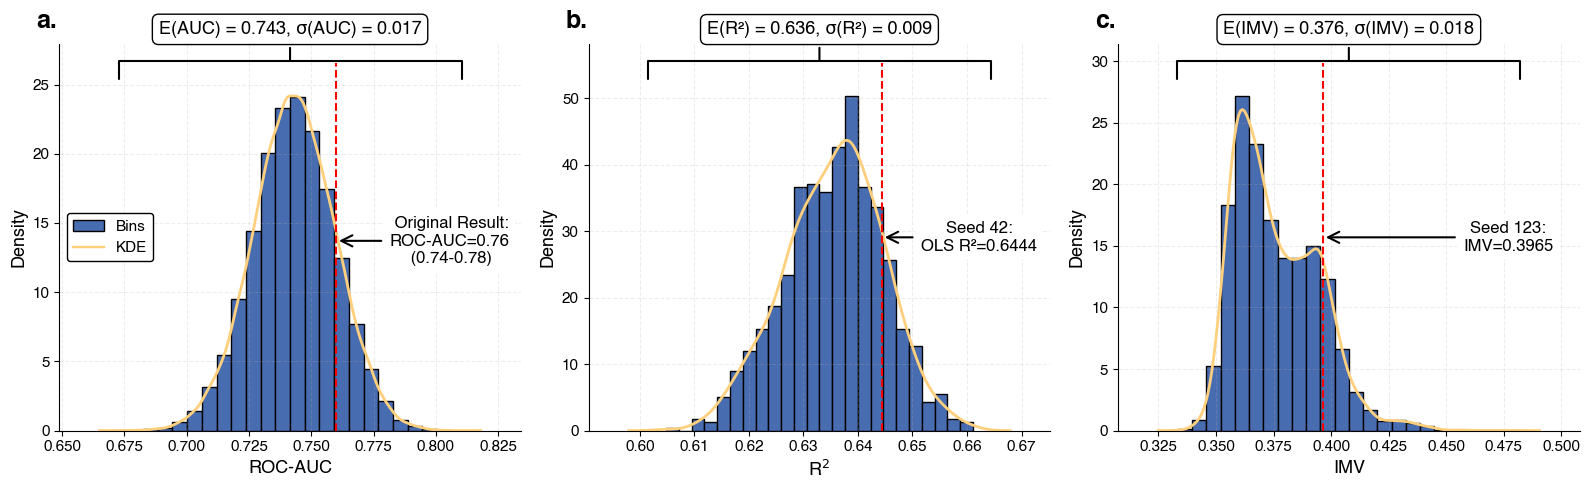

In [1]:
import os
filename = 'roc_auc_full_firstwave_5folds_10kseeds_stratified.csv'
figure_path = os.path.join(os.getcwd(), '..', 'figures')
color_list = ['#486cb0', '#fed07e', '#e75948']
from helper_figure_plotters import load_sympt, plot_predictions
first_wave_10k_stratified_list = load_sympt(filename)

from helper_figure_plotters import  plot_predictions_three_panel
plot_predictions_three_panel(first_wave_10k_stratified_list,
                             figure_path,
                             figsize=(16,5), colors=color_list)

Housing RF R2 (all folds): {'n': 1000000, 'min': 0.6258336870684655, 'max': 0.6843417408046817, 'mean': 0.6548514598910673, 'std': 0.008285955814060735, 'z': 79.03149311752621}
Housing RF modeling σ: {'n': 1000, 'min': 0.008078339074232893, 'max': 0.008453172983788969, 'mean': 0.00828973558066647, 'std': 5.2529190257891884e-05, 'z': 157.81198110932303}
Housing RF folding σ: {'n': 1000, 'min': 0.0011902166219227442, 'max': 0.0024596400280276027, 'mean': 0.0016747511833102603, 'std': 0.00019757279148025425, 'z': 8.476628642854589}
Titanic SGD IMV (all folds): {'n': 1000000, 'min': -0.1881, 'max': 0.3251, 'mean': -0.0342274963, 'std': 0.08103795838219387, 'z': -0.4223637537680202}
Titanic modeling σ: {'n': 1000, 'min': 0.07520139466658714, 'max': 0.08675475628885565, 'mean': 0.08099353117728562, 'std': 0.0017418779731274469, 'z': 46.497821562015716}
Titanic folding σ: {'n': 1000, 'min': 0.07203678311864074, 'max': 0.0907151535757851, 'mean': 0.07964766313359133, 'std': 0.00272307603865387

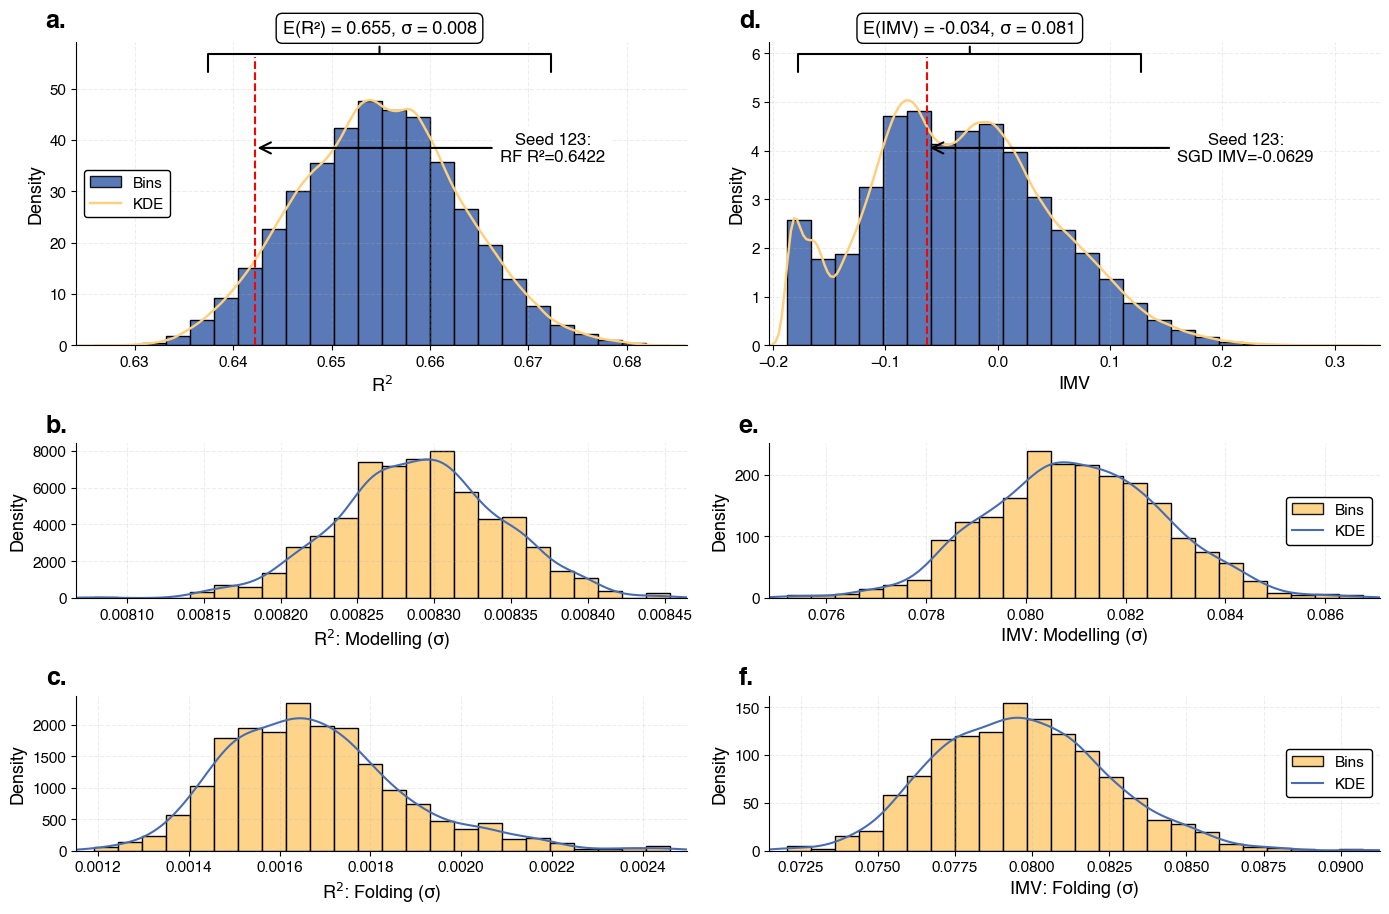

In [1]:
import os
color_list = ['#486cb0', '#fed07e', '#e75948']
figure_path = os.path.join(os.getcwd(), '..', 'figures')
from helper_figure_plotters import plot_housing_titanic_seed_sigma
plot_housing_titanic_seed_sigma(figure_path, figsize=(14, 5), colors=color_list)
